# Wstęp
##### Celem tej części projektu jest: Przeprowadzenie analizy zbioru danych związanych z miekszniami w Kaliforni
##### Skład zespołu: Konrad Wołkiewicz, Tymon Jażdżewski, Piotr Gawroński
##### Źródło danych: https://www.kaggle.com/datasets/camnugent/california-housing-prices/data


# Analiza Eksploracyjna Danych

#### Wczytujemy potrzebne biblioteki

In [30]:
import pandas as pd 
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.io as pio

#### Wczytujemy dane

In [31]:
df = pd.read_csv('data/housing.csv')

### Zbadanie zakresów i stopnia zmienności

In [32]:
display(df.head())
print(df.info())
print(df.describe())
print(df.describe(include=['O']))


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB
None
          longitude      latitude  housing_median_age   total_rooms  \
count  20640.000000  20640.000000        20640.000000  20640.000000   
mean    -119.569704     35.631861           28.639486   2635.763081   
std        2.003532      2.135952

- Mamy 10 kolumn:
    - długość geograficzna
    - szerokość geograficzna
    - mediana wieku budynków
    - całkowita liczba pokoi
    - całkowita liczba sypialni
    - populacja
    - ilość gospodarstw
    - mediana dochodów
    - mediana wartości domu
    - bliskość oceanu
- Mamy 20640 rekordów
- 9 kolumn jest typu float
- 1 kolumna (bliskość oceanu) jest typu Object, zawiera 5 unikalnych wartości z czego najczęściej występująca około 44% jest 'poniżej 1 godziny do oceanu' 

ocean_proximity
<1H OCEAN     44.263566
INLAND        31.739341
NEAR OCEAN    12.877907
NEAR BAY      11.094961
ISLAND         0.024225
Name: proportion, dtype: float64


<Axes: xlabel='ocean_proximity'>

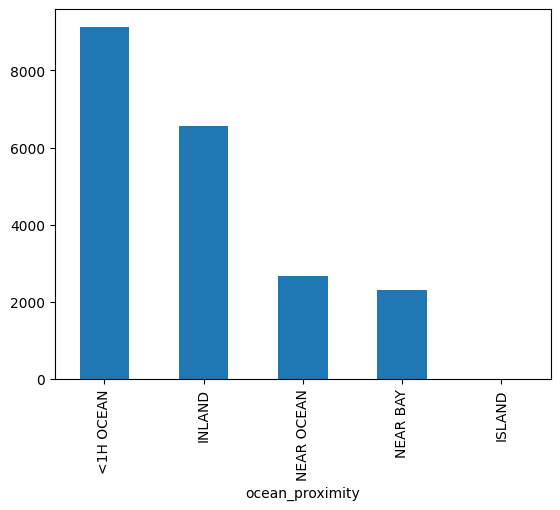

In [33]:
columns_without_ocean = df.columns
columns_without_ocean = columns_without_ocean[:-1]
ocean_proximity = df['ocean_proximity']
print(df['ocean_proximity'].value_counts(normalize=True)*100)
df['ocean_proximity'].value_counts().plot(kind='bar')

Elementy jakie występują w zmiennej ocean proximity to :
- 1<H OCEAN ~44%
- INLAND ~32%
- NEAR OCEAN ~13%
- NEAR BAY ~11%
- ISLAND ~0% 
  
Jako, że jest to zmienna kategoryczna nominalna (nie istnieje hierarchia) to zmienimy to skorzystamy z metody One-Hot Encoding

In [34]:
df = pd.get_dummies(df, columns=['ocean_proximity'], drop_first=True)

Teraz wykresy punktowe

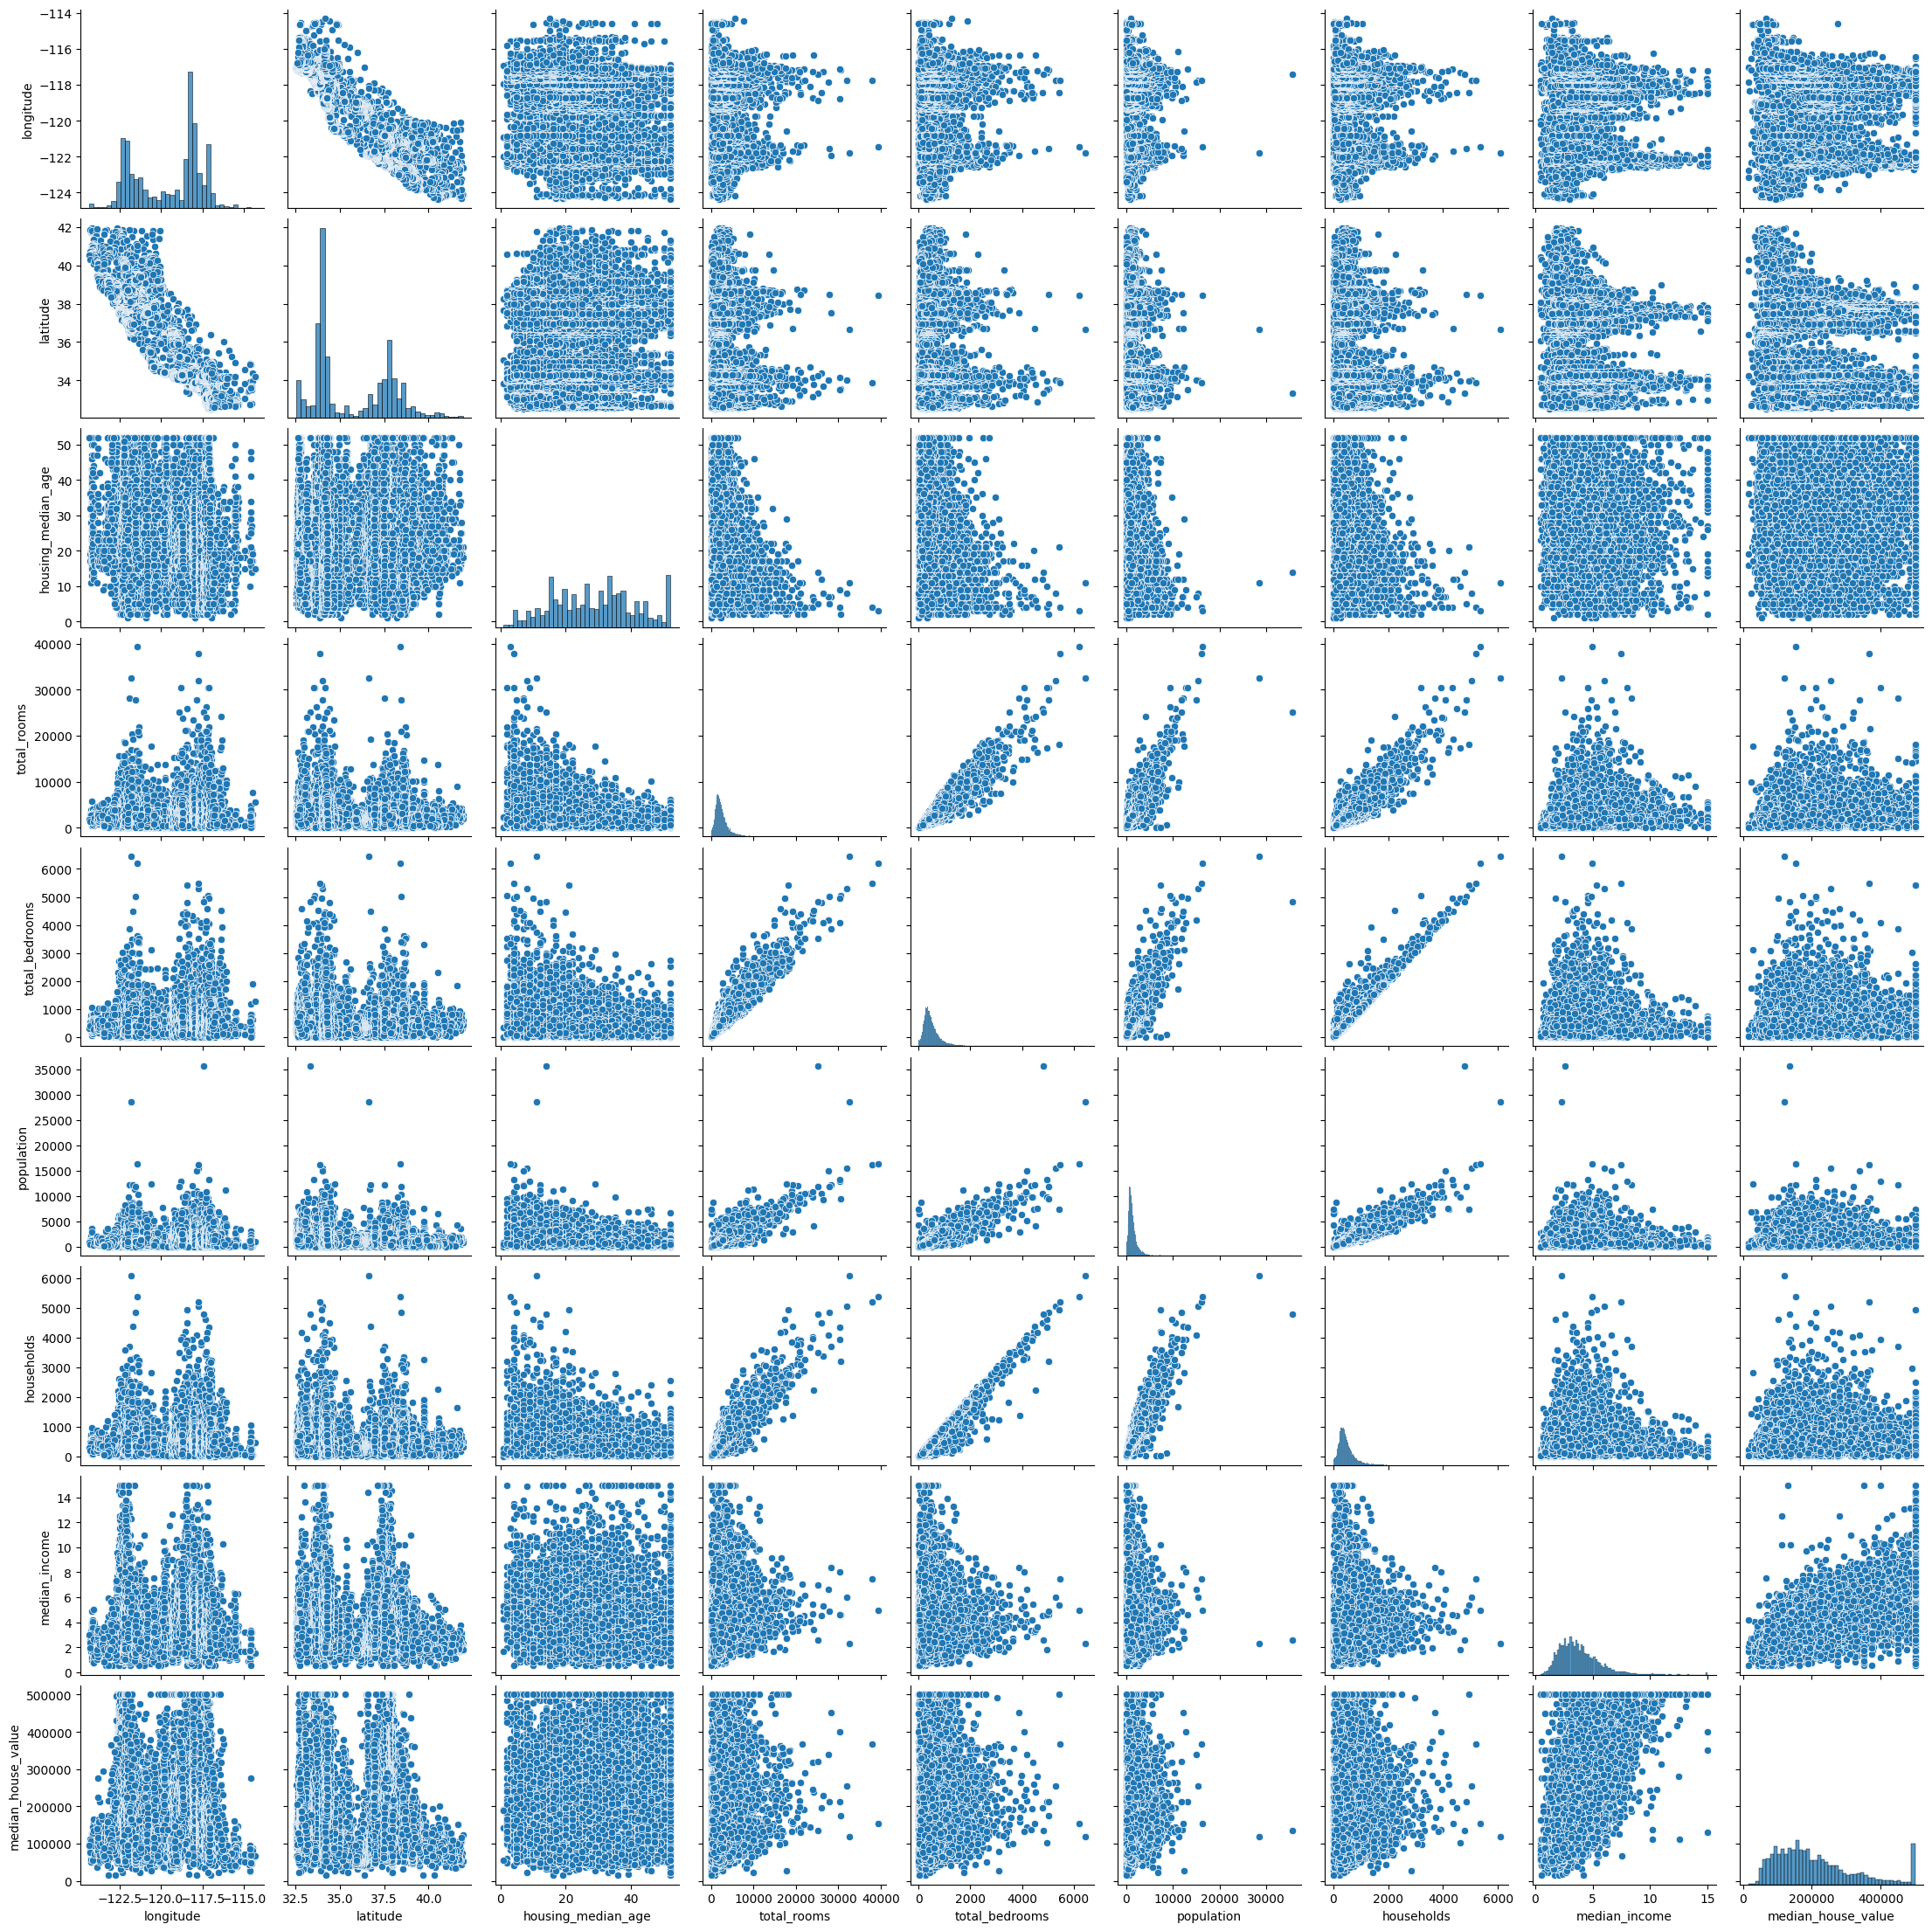

In [35]:
sns.pairplot(df[columns_without_ocean])
plt.show()

Z powyższych wykresów można wywnioskować, że:
1. Zmienna longitude jest bimodalna z szczytami w okolicach około -123, -117
2. Korelacja między longitude a latitude jest ujemna
3. Zmienna latitude również jest bimodalna z szczytami w okolicach 34, 37
4. Zmienna housing median age ma równomierną dystrybucje w granicach od 1 do 52
5. Większość wartości z total rooms ma wartość poniżej 5000, natomiast zawiera również wartości odstające do maksymalnie 39 320
6. Total rooms jest dodatnio skorelowana z total_bedrooms, population, households
7. Większość wartości z total bedrooms ma wartości poniżej 1500, natomiast zawiera również wartości odstające do maksymalnie 6445
8. Jest dodatnio skorelowana z population, households
9. Większość wartości z populations znajduje się poniżej 5000, natomiastma zawiera również wartości odstające do maksymalnie 35 682
10. Populations jest dodatnie skorelowana z households
11. Większość wartości z households znajduje się poniżej 1500, natomiastma zawiera również wartości odstające do maksymalnie 6082
12. Większość wartości z median_income znajduje się poniżej 8, natomiastma zawiera również wartości odstające do maksymalnie 15.0001
13. Cel median house value jest prawo skośna z medianą na poziomie 179 700, wartość minimlna 14 999, wartość maksymalna 50 0001. Jest ograniczona z góry do 500 001, dlatego wiele rekordów ma taką wartość

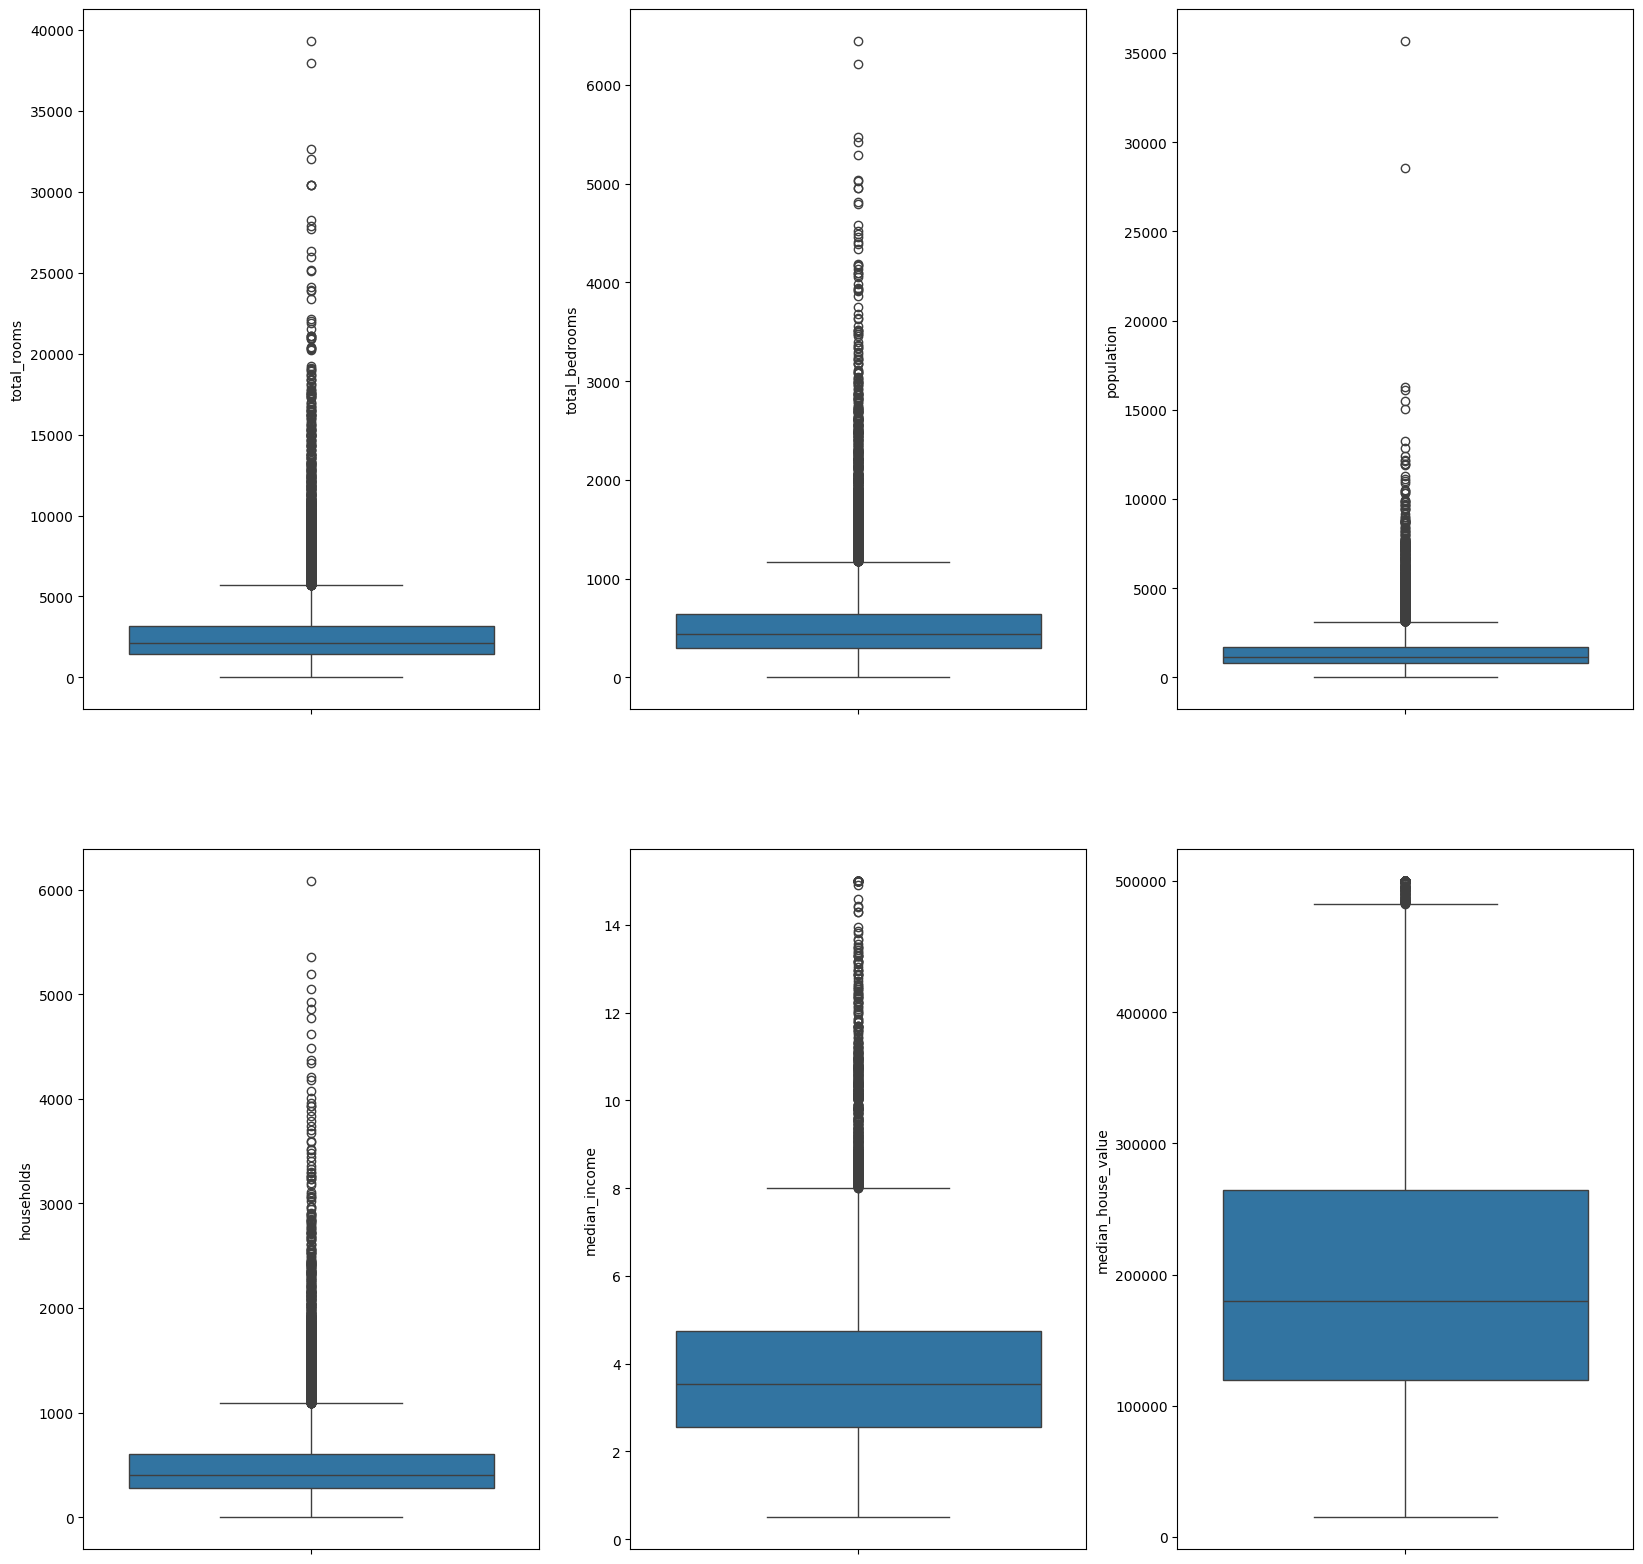

In [36]:
rows = 2
cols = 3
fig, ax = plt.subplots(rows, cols, figsize=(20, 20))
columns_to_boxplot = [ 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'median_house_value']
for i, col in enumerate(columns_to_boxplot):
    sns.boxplot(y=df[col], ax=ax[i//cols][i%cols])

Wykresy pudełkowe potwierdzają, że zmienne total_rooms, total_bedrooms, population, households, median_income zawierają bardzo dużo wartości odstajacych
Cel median_house_value również zawiera sporo wartości odstajacych ale nie tak dużo jak wymienione wcześniej zmienne

Weryfikacja punktów na mapie świata

In [37]:
pio.renderers.default = 'notebook_connected' # or iframe
fig = px.scatter_map(df, 
                     lat="latitude", 
                     lon="longitude", 
                     zoom=5, 
                     height=600)
fig.update_layout(mapbox_style="open-street-map")
fig.show()

Sprawdzmy jeszcze jak będzie wygladała relacja między odległością od oceana a naszym celem

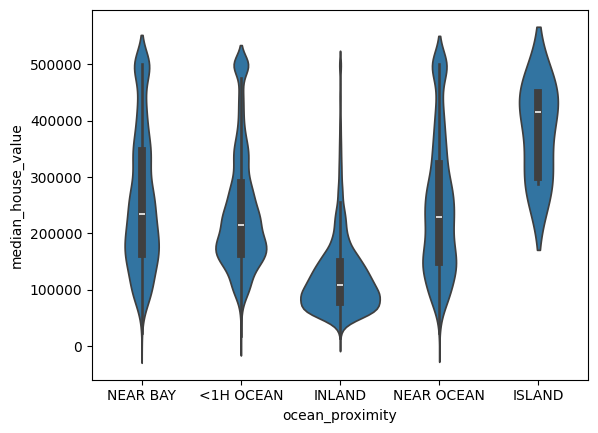

In [38]:
sns.violinplot(x=ocean_proximity, y=df['median_house_value'])
plt.show()

- Z wykresu można wywnioskować, że jeżeli dzielnica jest sklasyfikowana jako INLAND to raczej dom będzie tańszy 
- Z wykresu można również wywnioskować, że dzielnica sklasyfikowana jako ISLAND jest najdroższa, natomiast to raczje będzie stanowić marginalny wpływ ponieważ rekordów z taką zmienną jest w przybliżeniu 0.02%

### Sprawdzenie zależności miedzy danymi

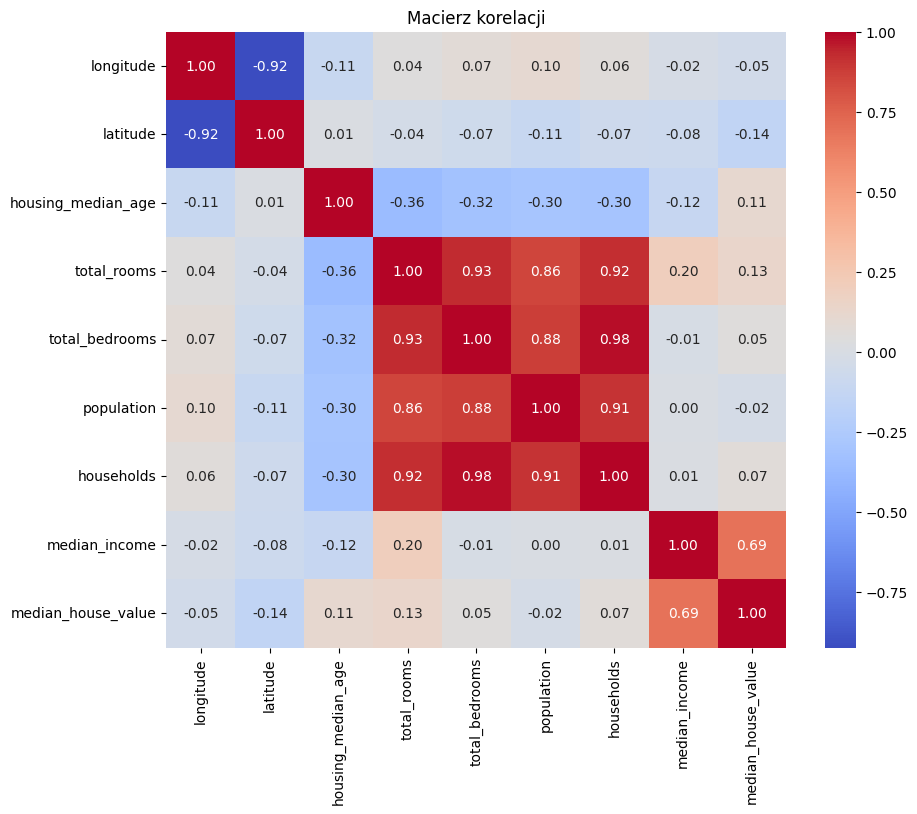

In [39]:
plt.figure(figsize=(10, 8))
sns.heatmap(df[columns_without_ocean].corr(numeric_only=True), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Macierz korelacji")
plt.show()

1. Jest silna korelacja ujemna między szerokością a długością geograficzną co było widać na mapie Kalifornii
2. Pomiędzy total_rooms, total_bedrooms, population, households jest silna korelacja dodatnia
3. Korelacja miedzy median income, a median house value wynosi 0.69, co nie było widać na wykresie punktowym

### Analiza stopnia wypełnienia danych

In [40]:
df.isna().sum()

longitude                       0
latitude                        0
housing_median_age              0
total_rooms                     0
total_bedrooms                207
population                      0
households                      0
median_income                   0
median_house_value              0
ocean_proximity_INLAND          0
ocean_proximity_ISLAND          0
ocean_proximity_NEAR BAY        0
ocean_proximity_NEAR OCEAN      0
dtype: int64

Jedynie kolumna związana z łaczną liczbą sypialni ma 207 braków. Sprawdźmy jak wyglądają te braki 

In [41]:
df[df['total_bedrooms'].isna()].head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
290,-122.16,37.77,47.0,1256.0,NaN,570.0,218.0,4.3750,161900.0,False,False,True,False
341,-122.17,37.75,38.0,992.0,NaN,732.0,259.0,1.6196,85100.0,False,False,True,False
538,-122.28,37.78,29.0,5154.0,NaN,3741.0,1273.0,2.5762,173400.0,False,False,True,False
563,-122.24,37.75,45.0,891.0,NaN,384.0,146.0,4.9489,247100.0,False,False,True,False
696,-122.10,37.69,41.0,746.0,NaN,387.0,161.0,3.9063,178400.0,False,False,True,False


Wygląda na to, że prawdopodobnie to był zwykły błąd zbeirania danych, że ta kolumna zawiera braki bo reszta kolumn w danym rekordzie ma normalne dane.
Sprawdźmy czy ta zmienna jest skorelowana z jakąś inną zmienną. Jeżeli nie jest to najprawdopodobniej najlepiej było by usupełnić medianą 

In [42]:
corr_matrix = df.corr(numeric_only=True)
print(corr_matrix['total_bedrooms'].sort_values(ascending=False))

total_bedrooms                1.000000
households                    0.979728
total_rooms                   0.930380
population                    0.877747
longitude                     0.069608
median_house_value            0.049686
ocean_proximity_NEAR OCEAN    0.000679
ocean_proximity_ISLAND       -0.004361
ocean_proximity_INLAND       -0.006463
median_income                -0.007723
ocean_proximity_NEAR BAY     -0.019873
latitude                     -0.066983
housing_median_age           -0.320451
Name: total_bedrooms, dtype: float64


Widzimy, że zmienna total_bedrooms jest najbardziej skorelowana z zmienną households (korelacja na poziomie 0.98), w tym celu obliczamy średni stosunek między ilością sypialni a ilością gospodarstw i następnie na tej podstawie będziemy uzupełniać braki

In [43]:
avg_bedrooms = df[df['total_bedrooms'].notna()]['total_bedrooms'].mean()
avg_household = df[df['total_bedrooms'].notna()]['households'].mean()
wsp = avg_bedrooms / avg_household
df['total_bedrooms'] = df['total_bedrooms'].fillna(wsp * df['households'])

df.to_csv('data/housing_final.csv', index=False)

### Hipoteza

Głównym czynnikiem determinującym medianę wartości nieruchomości w Kalifornii jest mediana dochodów mieszkańców. Drugim najważniejszym czynnikiem jest bliskość oceanu